In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [ ]:
kwh_data = data[['temp', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,cloudcover,solarradiation,conditions
datetime,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,41.7,0.0,Partially cloudy
...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,63.7,9.0,"Rain, Partially cloudy"


In [6]:
kwh_data.describe()

,temp,cloudcover,solarradiation
count,21983.000000,21983.000000,21983.000000
mean,13.414748,47.738025,176.537262
std,8.779722,38.837197,264.425914
min,-10.000000,0.000000,0.000000
25%,7.000000,4.800000,0.000000
50%,13.000000,49.100000,11.000000
75%,20.000000,88.300000,298.000000
max,40.000000,100.000000,1157.000000


In [7]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)
kwh_data['hour'] = kwh_data.index.hour
kwh_data['day'] = kwh_data.index.day
kwh_data['month'] = kwh_data.index.month
kwh_data

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_4640/4253170597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,cloudcover,solarradiation,conditions_int,hour,day,month
datetime,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7


In [8]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh
datetime,,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1,0.0000
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1,0.0000
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1,0.0000
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1,0.0000
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1,0.0000
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7,0.0592
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7,0.0085
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7,0.0000


In [9]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :11])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7
0,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
1,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
3,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
4,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
5,-1.186254,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890
6,-1.072353,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890
7,-0.844550,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890
8,-0.958452,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965
9,-0.844550,0.058244,-0.580657,0.662831,-0.361218,-1.662386,-1.452052,-0.234996


In [10]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7
datetime,,,,,,,,
2022-01-01 00:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
2022-01-01 01:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2022-01-01 02:00:00,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
2022-01-01 03:00:00,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
2022-01-01 04:00:00,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121
2024-07-04 20:00:00,1.091774,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731
2024-07-04 21:00:00,0.863971,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890


In [11]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh


,0,1,2,3,4,5,6,7,Kwh
datetime,,,,,,,,,
2022-01-01 00:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121,0.0592
2024-07-04 20:00:00,1.091774,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731,0.0085
2024-07-04 21:00:00,0.863971,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890,0.0000


In [12]:
def df_to_x_y(df, size = 24):
    df_as_np = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_np) - size):
        row = [a for a in df_as_np[i: i+size, :8]]
        x.append(row)
        real_val = df_as_np[i + size][8]
        y.append(real_val)
    
    return np.array(x), np.array(y)


In [13]:
x_kwh, y_kwh = df_to_x_y(df_scaled_kwh, size=24)
x_kwh.shape, y_kwh.shape

x_train_kwh, y_train_kwh = x_kwh[:int(0.9*len(x_kwh))], y_kwh[:int(0.9*len(y_kwh))]
x_val_kwh, y_val_kwh = x_kwh[int(0.9*len(x_kwh)):int(0.95*len(x_kwh))], y_kwh[int(0.9*len(y_kwh)):int(0.95*len(y_kwh))]
x_test_kwh, y_test_kwh = x_kwh[int(0.95*len(x_kwh)):], y_kwh[int(0.95*len(y_kwh)):]

x_train_kwh.shape, y_train_kwh.shape, x_val_kwh.shape, y_val_kwh.shape, x_test_kwh.shape, y_test_kwh.shape

((19763, 24, 8), (19763,), (1098, 24, 8), (1098,), (1098, 24, 8), (1098,))

In [14]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [15]:
input_shape = (24, 8)

inputs = Input(shape=input_shape)

cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(cnn_out)
cnn_out = AveragePooling1D(pool_size=2)(cnn_out)
cnn_out = BatchNormalization()(cnn_out)

query = cnn_out
value = cnn_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

lstm_out = LSTM(128, return_sequences=True)(cnn_out)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out
multihead_attention_out = MultiHeadAttention(num_heads=8, key_dim=128)(query, value)

dropout_out = Dropout(0.1)(multihead_attention_out)

dense_out = Dense(128, activation="relu")(dropout_out)

flattened = BatchNormalization()(dense_out)
flattened = GlobalAveragePooling1D()(flattened)

outputs = Dense(1, activation="linear")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      1,600 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 12, 64)    │          0 │ conv1d[0][0]      │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 64)    │        256 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_1 │ (None, 6, 128)    │          0 │ conv1d_1[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ average_pooling1… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 6, 128)    │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 128)    │    527,488 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 6, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 128)    │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 128)    │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 703,809 (2.68 MB)

 Trainable params: 702,913 (2.68 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
import time 

start = time.time()
history = model_1.fit(x_train_kwh, y_train_kwh, 
            validation_data=(x_val_kwh, y_val_kwh), 
            epochs=40,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/40
1232/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1458 - root_mean_squared_error: 0.3176
Epoch 1: val_loss improved from inf to 0.01544, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.1454 - root_mean_squared_error: 0.3172 - val_loss: 0.0154 - val_root_mean_squared_error: 0.1246 - learning_rate: 0.0010
Epoch 2/40
1233/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114 - root_mean_squared_error: 0.1069
Epoch 2: val_loss improved from 0.01544 to 0.01056, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0114 - root_mean_squared_error: 0.1069 - val_loss: 0.0106 - val_root_mean_squared_error: 0.1030 - learning_rate: 0.0010
Epoch 3/40
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0084 - root_mean_squared_error: 0.0918
Epoch 3: val_loss did not improve from 0.01056
1236/1236 ━━━━━━━━━━━━━━

In [17]:
print(f"{round((end - start) / 60, 5)} mins")

7.81836 mins


In [18]:
test_predictions_kwh = model_1.predict(x_test_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_test_kwh})
test_results_kwh['Val Predictions'] = round(test_results_kwh['Val Predictions'], 4)
test_results_kwh.index = kwh_data.iloc[-1098:].index
test_results_kwh

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,Val Predictions,Real Data
datetime,,
2024-05-20 06:00:00,0.0037,0.0016
2024-05-20 07:00:00,0.0454,0.0463
2024-05-20 08:00:00,0.1666,0.1792
2024-05-20 09:00:00,0.3533,0.4355
2024-05-20 10:00:00,0.4953,0.5716
...,...,...
2024-07-04 19:00:00,0.1252,0.0592
2024-07-04 20:00:00,0.0194,0.0085
2024-07-04 21:00:00,0.0042,0.0000


In [19]:
test_results_kwh.head(48)

,Val Predictions,Real Data
datetime,,
2024-05-20 06:00:00,0.0037,0.0016
2024-05-20 07:00:00,0.0454,0.0463
2024-05-20 08:00:00,0.1666,0.1792
2024-05-20 09:00:00,0.3533,0.4355
2024-05-20 10:00:00,0.4953,0.5716
2024-05-20 11:00:00,0.6182,0.5960
2024-05-20 12:00:00,0.6040,0.6821
2024-05-20 13:00:00,0.6234,0.7122
2024-05-20 14:00:00,0.6298,0.6767


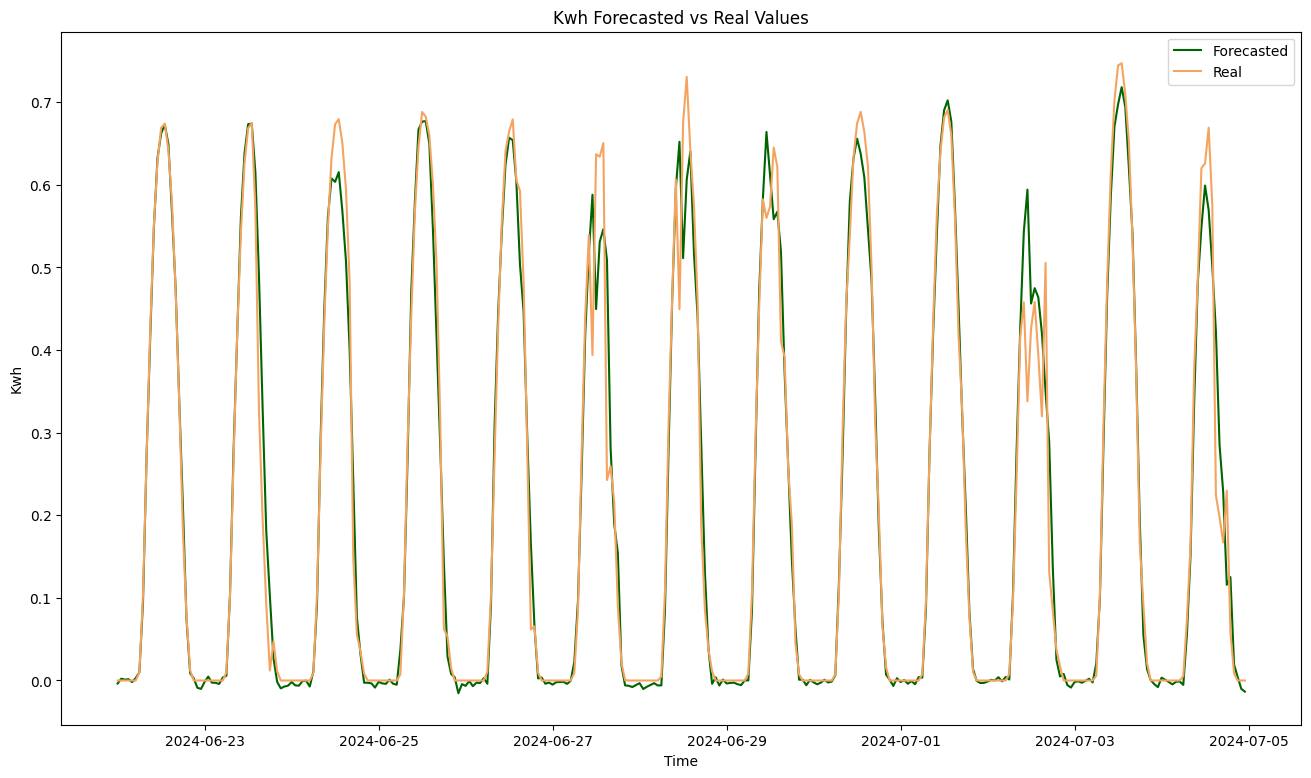

In [20]:
plt.figure(figsize=(16, 9))
sns.lineplot(x = test_results_kwh.index[-312: ], y = test_results_kwh["Val Predictions"][-312: ], label="Forecasted", color = 'DarkGreen')
sns.lineplot(x = test_results_kwh.index[-312: ], y = test_results_kwh["Real Data"][-312: ], label="Real", color = 'SandyBrown')
plt.legend()
plt.ylabel("Kwh")
plt.xlabel("Time")
plt.title("Kwh Forecasted vs Real Values")
plt.show()


In [24]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

mean_real_data = test_results_kwh["Real Data"].mean()
mse_percent = (mse_kwh / mean_real_data) * 100

r_squared_kwh, mse_kwh, mse_percent    
                                       #0.95047 --> 95.047% with batch_size = 32
                                       #0.95281 --> 95.281% with batch_size = 16
                                       #0.93819 --> 93.819% with batch_size = 64
                                       #0.94705 --> 94.705% with batch_size = 8

Mean Squared Error = 0.00297 
Root Mean Squared Error = 0.05451


(0.9547879974668384, 0.0029711782571088152, 1.3511877840957671)

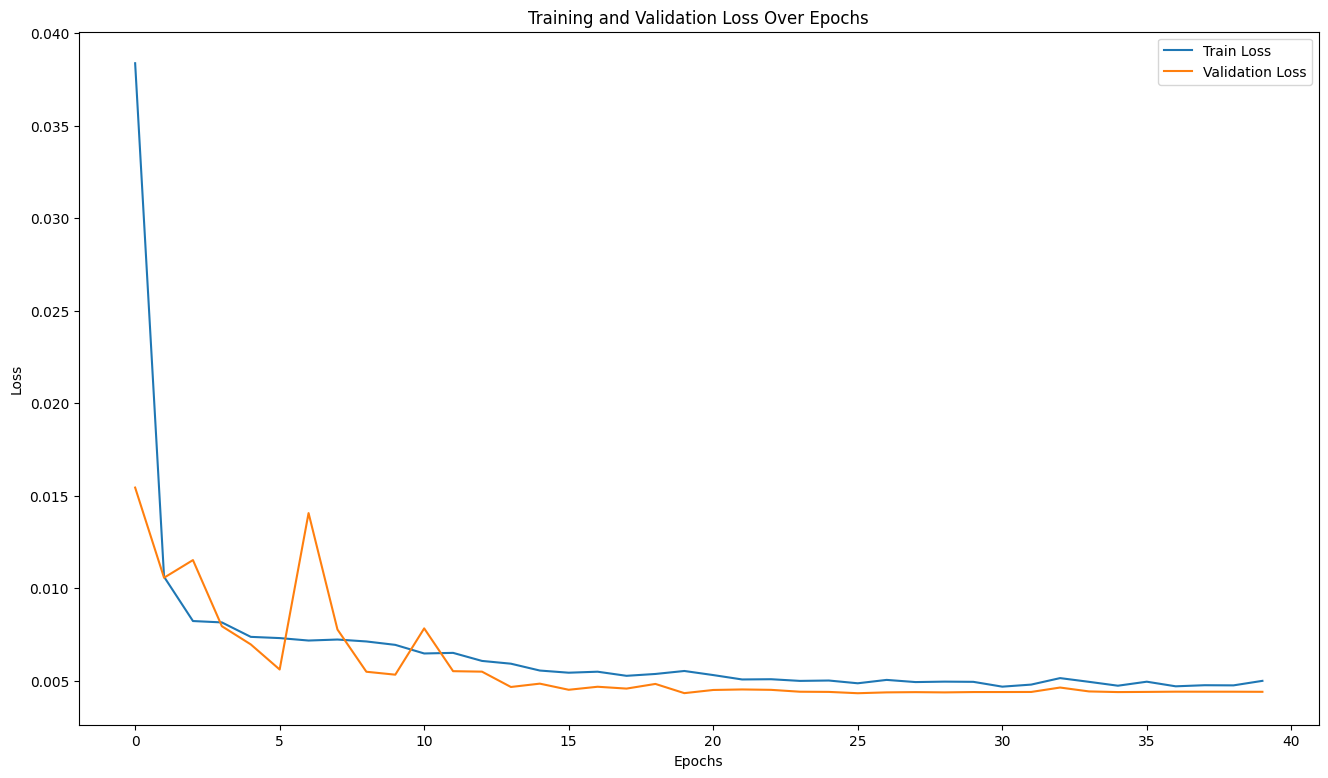

In [25]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

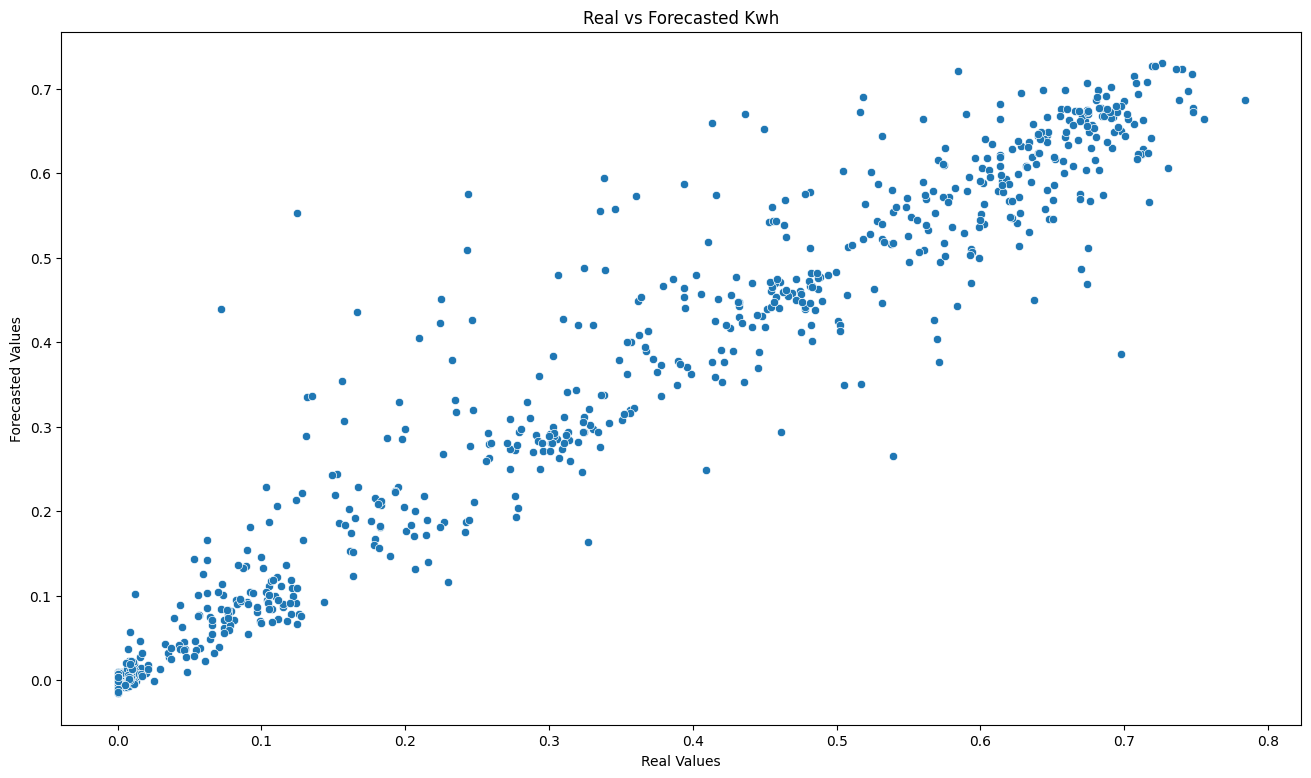

In [23]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results_kwh)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.title("Real vs Forecasted Kwh")
plt.show()

In [24]:
kwh_data_winter = df_scaled_kwh[(df_scaled_kwh.index > "2023-11-01 00:00:00") & (df_scaled_kwh.index < "2024-03-01 00:00:00")]
kwh_data_winter

,0,1,2,3,4,5,6,7,Kwh
datetime,,,,,,,,,
2023-11-01 01:00:00,-0.047240,1.345699,-0.66764,-0.232745,-1.516935,-1.662386,1.494705,-0.67989,0.0
2023-11-01 02:00:00,-0.047240,1.345699,-0.66764,2.453984,-1.372470,-1.662386,1.494705,-0.67989,0.0
2023-11-01 03:00:00,-0.161142,1.075333,-0.66764,0.662831,-1.228006,-1.662386,1.494705,-0.67989,0.0
2023-11-01 04:00:00,-0.161142,1.345699,-0.66764,-0.232745,-1.083541,-1.662386,1.494705,-0.67989,0.0
2023-11-01 05:00:00,-0.275043,1.010960,-0.66764,0.662831,-0.939076,-1.662386,1.494705,-0.67989,0.0
...,...,...,...,...,...,...,...,...,...
2024-02-29 19:00:00,-0.161142,1.345699,-0.66764,-0.232745,1.083429,1.514111,-1.157376,-0.67989,0.0
2024-02-29 20:00:00,-0.388945,1.345699,-0.66764,2.453984,1.227894,1.514111,-1.157376,-0.67989,0.0
2024-02-29 21:00:00,-0.388945,1.345699,-0.66764,-0.232745,1.372359,1.514111,-1.157376,-0.67989,0.0


In [25]:
x_kwh, y_kwh = df_to_x_y(kwh_data_winter, size=24)
x_kwh.shape, y_kwh.shape


((2879, 24, 8), (2879,))

In [26]:
test_predictions_kwh = model_1.predict(x_kwh).flatten()
test_results_kwh = pd.DataFrame({"Val Predictions": test_predictions_kwh, "Real Data": y_kwh})
test_results_kwh
test_results_kwh.index = kwh_data_winter.iloc[-2855:].index

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


ValueError: Length mismatch: Expected axis has 2879 elements, new values have 2855 elements

In [ ]:
plt.figure(figsize=(16, 9))
sns.lineplot(x = test_results_kwh.index[-312: ], y = test_results_kwh["Val Predictions"][-312: ], label="Forecasted", color = 'DarkGreen')
sns.lineplot(x = test_results_kwh.index[-312: ], y = test_results_kwh["Real Data"][-312: ], label="Real", color = 'SandyBrown')
plt.legend()
plt.ylabel("Kwh")
plt.xlabel("Time")
plt.title("Kwh Forecasted vs Real Values")
plt.show()


In [ ]:
mse_kwh = mean_squared_error(test_results_kwh["Real Data"], test_results_kwh["Val Predictions"])
print(f"Mean Squared Error = {round(mse_kwh, 5)} \nRoot Mean Squared Error = {round(np.sqrt(mse_kwh), 5)}")

ss_total = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Real Data"].mean()) ** 2)
residual = np.sum((test_results_kwh["Real Data"] - test_results_kwh["Val Predictions"]) ** 2)
r_squared_kwh = 1 - (residual / ss_total)

mean_real_data = test_results_kwh["Real Data"].mean()
mse_percent = (mse_kwh / mean_real_data) * 100

r_squared_kwh, mse_kwh, mse_percent    
                                       #0.95047 --> 95.047% with batch_size = 32
                                       #0.95147 --> 95.147% with batch_size = 16
                                       #0.93819 --> 93.819% with batch_size = 64
                                       #0.94705 --> 94.705% with batch_size = 8

# Outliers with the Conditions as Input

In [26]:
test_results_kwh['Error'] = test_results_kwh['Real Data'] - test_results_kwh['Val Predictions']
test_results_kwh

,Val Predictions,Real Data,Error
datetime,,,
2024-05-20 06:00:00,0.0037,0.0016,-0.0021
2024-05-20 07:00:00,0.0454,0.0463,0.0009
2024-05-20 08:00:00,0.1666,0.1792,0.0126
2024-05-20 09:00:00,0.3533,0.4355,0.0822
2024-05-20 10:00:00,0.4953,0.5716,0.0763
...,...,...,...
2024-07-04 19:00:00,0.1252,0.0592,-0.0660
2024-07-04 20:00:00,0.0194,0.0085,-0.0109
2024-07-04 21:00:00,0.0042,0.0000,-0.0042


In [55]:
Q1 = test_results_kwh['Error'].quantile(0.25)
Q3 = test_results_kwh['Error'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 6 * IQR
upper_bound = Q3 + 5 * IQR

# Find the outliers
outliers = test_results_kwh[(test_results_kwh['Error'] < lower_bound) | (test_results_kwh['Error'] > upper_bound)]
print(outliers)

                     Val Predictions  Real Data   Error
datetime                                               
2024-05-21 15:00:00           0.5004     0.5991  0.0987
2024-05-22 12:00:00           0.7217     0.5844 -0.1373
2024-05-22 14:00:00           0.5463     0.6479  0.1016
2024-05-23 13:00:00           0.6903     0.5182 -0.1721
2024-05-23 15:00:00           0.4267     0.5674  0.1407
...                              ...        ...     ...
2024-07-02 16:00:00           0.3498     0.5054  0.1556
2024-07-02 17:00:00           0.2890     0.1310 -0.1580
2024-07-04 13:00:00           0.5693     0.6692  0.0999
2024-07-04 15:00:00           0.4228     0.2240 -0.1988
2024-07-04 18:00:00           0.1158     0.2298  0.1140

[67 rows x 3 columns]


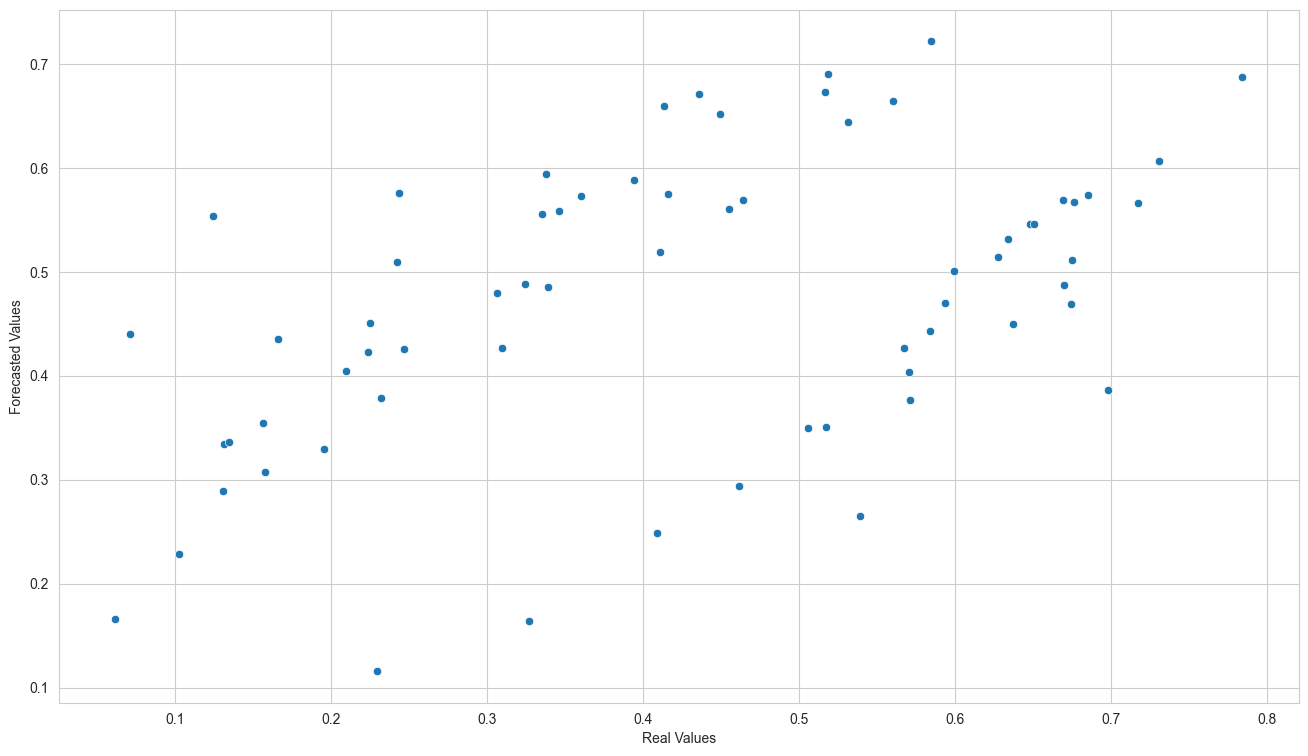

In [56]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = outliers)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [57]:
common_index = data.index.intersection(outliers.index)

initial_df_outliers = data.loc[common_index]

initial_df_outliers

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2024-05-21 15:00:00,0.5991,"Kozani, Greece",25.0,25.0,12.0,44.30,0.0,0.0,0.0,30.0,11.2,180.0,1015.0,80.0,20.0,206.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-05-22 12:00:00,0.5844,"Kozani, Greece",25.0,25.0,11.0,41.46,0.0,0.0,0.0,15.3,0.0,0.0,1013.0,50.0,10.0,841.0,3.0,8.0,Partially cloudy,partly-cloudy-day
2024-05-22 14:00:00,0.6479,"Kozani, Greece",26.0,26.0,8.0,31.92,0.0,0.0,0.0,12.2,0.0,0.0,1012.0,50.0,10.0,220.0,0.8,2.0,Partially cloudy,partly-cloudy-day
2024-05-23 13:00:00,0.5182,"Kozani, Greece",24.0,24.0,5.0,29.26,0.0,0.0,0.0,32.8,13.0,360.0,1015.0,50.0,10.0,928.0,3.3,9.0,Partially cloudy,partly-cloudy-day
2024-05-23 15:00:00,0.5674,"Kozani, Greece",23.0,23.0,4.0,28.97,0.0,0.0,0.0,25.9,5.4,310.0,1015.0,55.4,24.1,998.0,3.6,10.0,Partially cloudy,partly-cloudy-day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-02 16:00:00,0.5054,"Kozani, Greece",33.0,30.8,6.0,18.58,0.0,0.0,0.0,38.2,9.4,140.0,1006.0,95.2,NaN,498.0,1.8,5.0,Overcast,cloudy
2024-07-02 17:00:00,0.1310,"Kozani, Greece",36.0,33.5,5.0,14.67,0.0,0.0,0.0,48.2,9.4,270.0,1005.0,100.0,NaN,615.0,2.2,6.0,Overcast,cloudy
2024-07-04 13:00:00,0.6692,"Kozani, Greece",25.0,25.0,8.0,33.87,0.0,0.0,0.0,20.2,16.6,320.0,1009.0,25.0,10.0,262.0,0.9,3.0,Partially cloudy,partly-cloudy-day


In [58]:
initial_df_outliers['time'] = initial_df_outliers.index.time
initial_df_outliers

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,...,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon,time
datetime,,,,,,,,,,,,,,,,,,,,,
2024-05-21 15:00:00,0.5991,"Kozani, Greece",25.0,25.0,12.0,44.30,0.0,0.0,0.0,30.0,...,180.0,1015.0,80.0,20.0,206.0,0.7,2.0,Partially cloudy,partly-cloudy-day,15:00:00
2024-05-22 12:00:00,0.5844,"Kozani, Greece",25.0,25.0,11.0,41.46,0.0,0.0,0.0,15.3,...,0.0,1013.0,50.0,10.0,841.0,3.0,8.0,Partially cloudy,partly-cloudy-day,12:00:00
2024-05-22 14:00:00,0.6479,"Kozani, Greece",26.0,26.0,8.0,31.92,0.0,0.0,0.0,12.2,...,0.0,1012.0,50.0,10.0,220.0,0.8,2.0,Partially cloudy,partly-cloudy-day,14:00:00
2024-05-23 13:00:00,0.5182,"Kozani, Greece",24.0,24.0,5.0,29.26,0.0,0.0,0.0,32.8,...,360.0,1015.0,50.0,10.0,928.0,3.3,9.0,Partially cloudy,partly-cloudy-day,13:00:00
2024-05-23 15:00:00,0.5674,"Kozani, Greece",23.0,23.0,4.0,28.97,0.0,0.0,0.0,25.9,...,310.0,1015.0,55.4,24.1,998.0,3.6,10.0,Partially cloudy,partly-cloudy-day,15:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-02 16:00:00,0.5054,"Kozani, Greece",33.0,30.8,6.0,18.58,0.0,0.0,0.0,38.2,...,140.0,1006.0,95.2,NaN,498.0,1.8,5.0,Overcast,cloudy,16:00:00
2024-07-02 17:00:00,0.1310,"Kozani, Greece",36.0,33.5,5.0,14.67,0.0,0.0,0.0,48.2,...,270.0,1005.0,100.0,NaN,615.0,2.2,6.0,Overcast,cloudy,17:00:00
2024-07-04 13:00:00,0.6692,"Kozani, Greece",25.0,25.0,8.0,33.87,0.0,0.0,0.0,20.2,...,320.0,1009.0,25.0,10.0,262.0,0.9,3.0,Partially cloudy,partly-cloudy-day,13:00:00


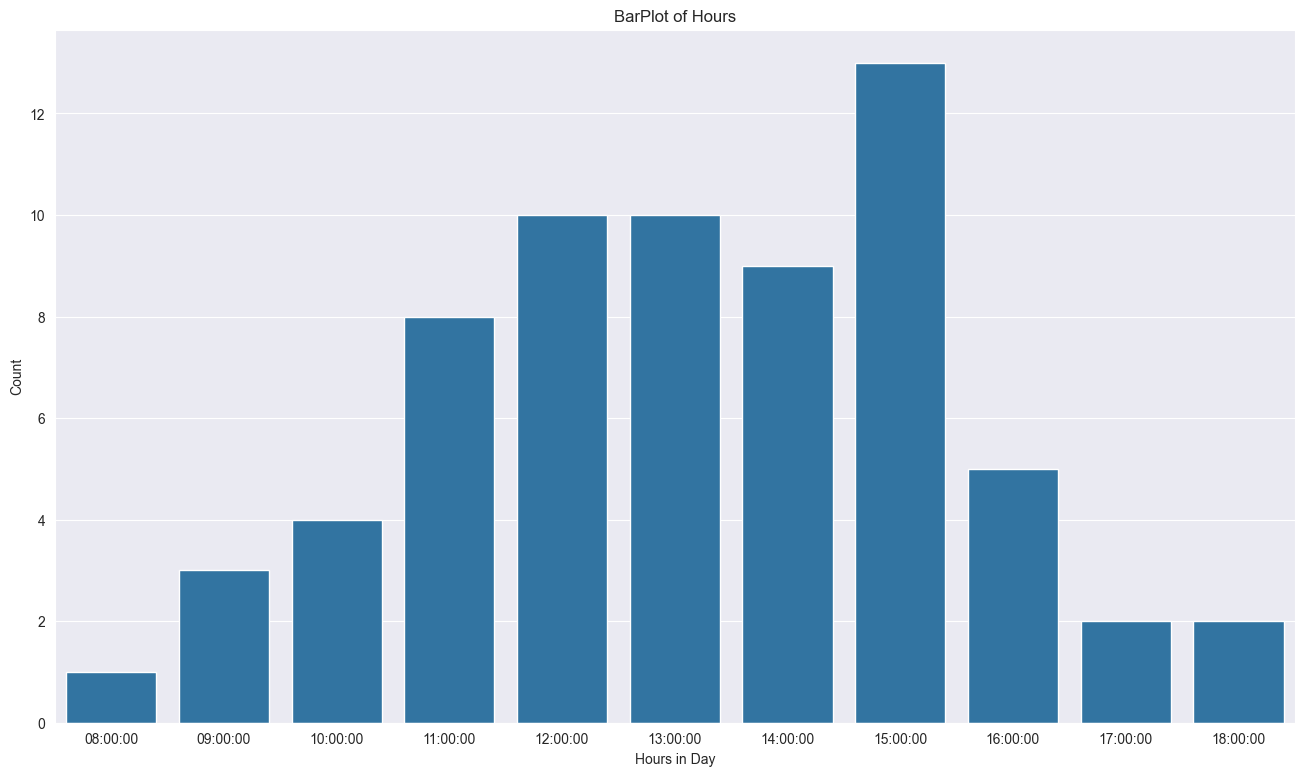

In [59]:
sns.set_style('darkgrid')
plt.figure(figsize= (16, 9))
sns.countplot(x = sorted(initial_df_outliers['time']))
plt.xlabel('Hours in Day')
plt.ylabel("Count")
plt.title("BarPlot of Hours")
plt.show()

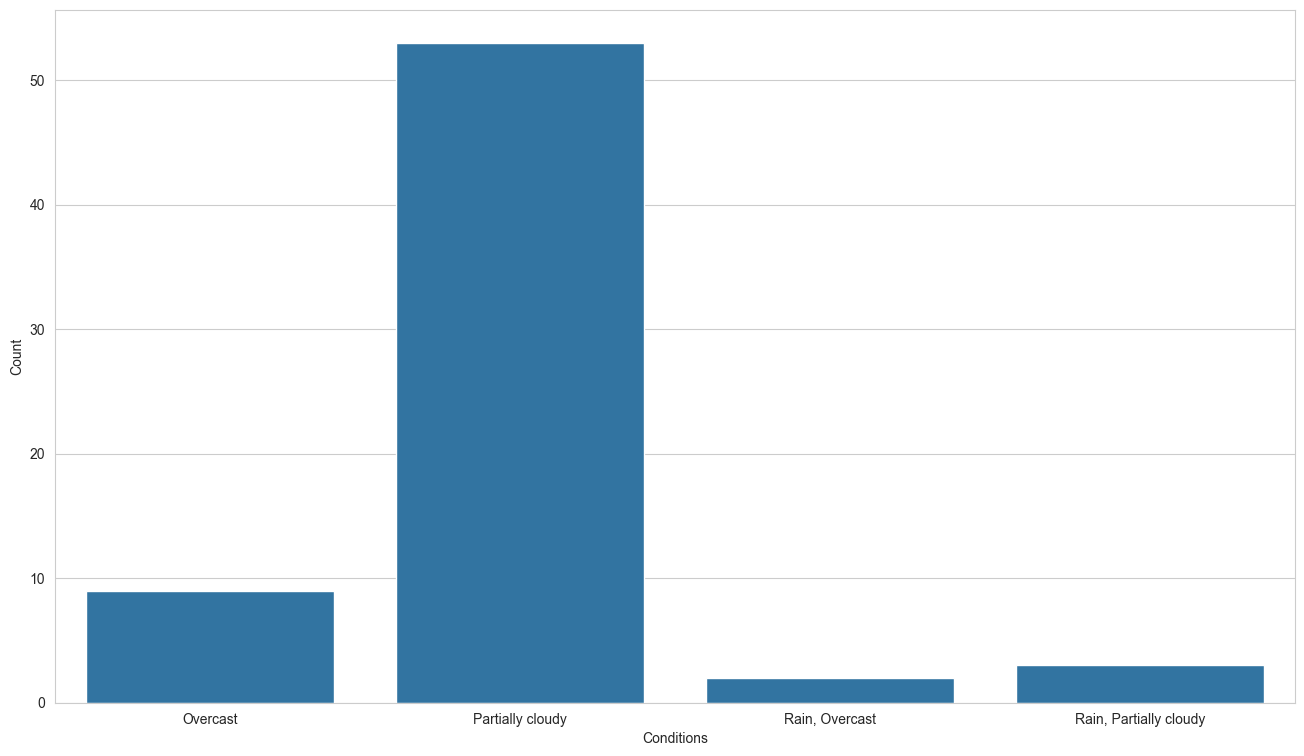

In [60]:
sns.set_style('whitegrid')
plt.figure(figsize= (16, 9))
sns.countplot(x = sorted(initial_df_outliers['conditions']))
plt.xlabel('Conditions')
plt.ylabel("Count")
#plt.title("BarPlot of Conditions in Outliers")
plt.show()